# Лабораторная работа 2: Обучение с учителем. Задача регрессии

**Датасет:** `cars_end.csv` — предсказание цены автомобиля (`price_usd`)  
**Модели:** SimpleLinearRegression, MultipleLinearRegression, Lasso, Ridge, ElasticNet, Polynomial, BayesianRidge, HuberRegressor  
**Поиск гиперпараметров:** GridSearchCV + RandomizedSearchCV + Optuna для каждой регуляризованной модели  
**Пользовательские метрики:** вынесены в `metrics.py`, подключены как библиотека

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from IPython.display import Markdown, display, Image

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import (LinearRegression, Lasso, Ridge, ElasticNet,
                                   BayesianRidge, HuberRegressor)
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import metrics as cm  # пользовательские метрики из metrics.py

## 1. Загрузка и подготовка данных

Загружаем предобработанный датасет, выделяем целевую переменную `price_usd`, разбиваем на train/test (80/20).

In [30]:
data = pd.read_csv("cars_end.csv")

target = 'price_usd'
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (30792, 47) Test: (7699, 47)


## 2. Вспомогательные функции

- `create_pipeline` — `PolynomialFeatures → StandardScaler → model`
- `create_simple_pipeline` — `StandardScaler → model` (без poly, для Bayesian/Robust)
- `run_search` — обёртка GridSearchCV / RandomizedSearchCV (`simple=True` для pipeline без poly)
- `plot_predictions` — scatter Predicted vs Actual
- `add_results` — добавляет метрики модели в обе таблицы результатов

In [31]:
def create_pipeline(model, degree=1):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

def create_simple_pipeline(model):
    """Pipeline без полиномиальных признаков (для Bayesian, Robust регрессий)."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

In [32]:
def sklearn_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

In [33]:
def run_search(model, param_grid, search_type="grid", n_iter=10, simple=False):
    pipe = create_simple_pipeline(model) if simple else create_pipeline(model)
    if search_type == "grid":
        search = GridSearchCV(pipe, param_grid, cv=CV_FOLDS, scoring='r2', n_jobs=1)
    else:
        search = RandomizedSearchCV(pipe, param_grid, n_iter=n_iter,
                                    cv=CV_FOLDS, scoring='r2', n_jobs=1, random_state=42)
    search.fit(X_train, y_train)
    return search.best_estimator_, search.best_params_

In [34]:
def plot_predictions(model, title, X=None, y_true=None):
    X = X_test if X is None else X
    y_true = y_test if y_true is None else y_true
    y_pred = model.predict(X)
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_pred, alpha=0.3, s=5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [35]:
results_t1 = []  # Образец 1: Train | Test для каждой модели
results_t2 = []  # Образец 2: sklearn vs пользовательские метрики
model_registry = {}
CV_FOLDS = 3  # уменьшаем число фолдов, чтобы ноутбук выполнялся быстрее

def add_results(name, model, X_tr=None, X_te=None, feature_names=None):
    """Вычисляет метрики, добавляет в обе таблицы, строит график."""
    X_tr = X_train if X_tr is None else X_tr
    X_te = X_test  if X_te is None else X_te
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    if feature_names is None:
        feature_names = list(X_tr.columns) if hasattr(X_tr, "columns") else [f"x{i}" for i in range(X_tr.shape[1])]

    def sk(yt, yp):
        return {"R2":   round(r2_score(yt, yp), 4),
                "MSE":  round(mean_squared_error(yt, yp), 4),
                "RMSE": round(sqrt(mean_squared_error(yt, yp)), 4),
                "MAE":  round(mean_absolute_error(yt, yp), 4),
                "MAPE": round(mean_absolute_percentage_error(yt, yp), 4)}

    train_m  = sk(y_train, y_pred_train)
    test_sk  = sk(y_test,  y_pred_test)
    test_cm  = cm.all_metrics(y_test, y_pred_test)

    results_t1.append({"Регрессор": name,
                        **{f"Train {k}": v for k, v in train_m.items()},
                        **{f"Test {k}":  v for k, v in test_sk.items()}})

    results_t2.append({"Регрессор": name,
                        **{f"sk {k}": v for k, v in test_sk.items()},
                        **{f"my {k}": v for k, v in test_cm.items()}})

    model_registry[name] = {
        "model": model,
        "feature_names": list(feature_names)
    }

    plot_predictions(model, name, X_te, y_test)

## 3.1. Простая линейная регрессия

Один признак — тот, у которого наибольшая корреляция с `price_usd`.

Особенности модели:
- использует только один наиболее информативный признак;
- легко интерпретируется и позволяет увидеть базовую линейную зависимость;
- обычно уступает более сложным моделям, если целевая переменная зависит сразу от многих факторов.

Лучший признак для простой линейной регрессии: year_produced
Корреляция с target: 0.7038


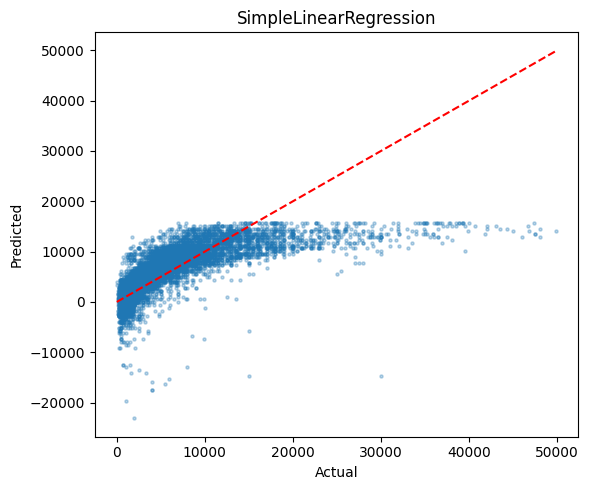

In [36]:
corr_with_target = pd.concat([X_train, y_train], axis=1).corr(numeric_only=True)[target].drop(target)
best_feature = corr_with_target.abs().idxmax()

X_train_simple = X_train[[best_feature]]
X_test_simple = X_test[[best_feature]]

model_simple = create_simple_pipeline(LinearRegression())
model_simple.fit(X_train_simple, y_train)

print(f"Лучший признак для простой линейной регрессии: {best_feature}")
print(f"Корреляция с target: {corr_with_target[best_feature]:.4f}")
add_results("SimpleLinearRegression", model_simple, X_train_simple, X_test_simple, [best_feature])

## 3.2. Множественная линейная регрессия

Используем все 47 признаков. Для моделей с регуляризацией подбираем гиперпараметры **тремя методами**: GridSearchCV, RandomizedSearchCV, Optuna — берём лучший по Test R².

### 3.2.1. LinearRegression (без регуляризации)

Особенности модели:
- учитывает вклад сразу всех признаков в предсказание цены;
- хорошо подходит как базовая модель для сравнения с регуляризованными методами;
- может переобучаться или быть неустойчивой при сильной корреляции между признаками.

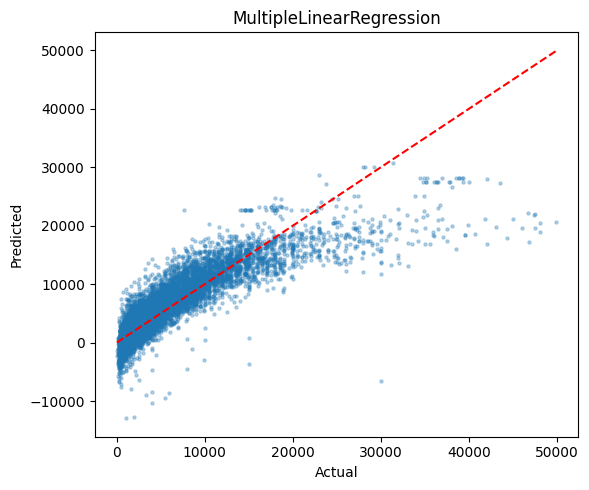

In [37]:
model_multi = create_simple_pipeline(LinearRegression())
model_multi.fit(X_train, y_train)
add_results("MultipleLinearRegression", model_multi)

### 3.2.2. Lasso (L1-регуляризация)

Особенности модели:
- добавляет L1-штраф к коэффициентам и может занулять часть из них;
- фактически выполняет отбор признаков, оставляя наиболее важные;
- полезна, когда нужно упростить модель и снизить влияние лишних признаков.

Grid    : R²=0.7307
Random  : R²=0.7307
Optuna  : R²=0.7308

Лучший метод: Optuna


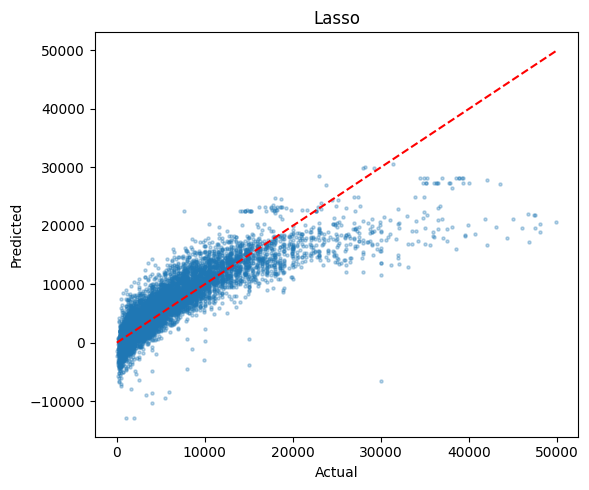

In [38]:
pg_lasso = {
    "poly__degree": [1],
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_grid, p1 = run_search(Lasso(max_iter=5000), pg_lasso, "grid")
lasso_rnd,  p2 = run_search(Lasso(max_iter=5000), pg_lasso, "random", n_iter=5)

def obj_lasso(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 10, log=True)
    return cross_val_score(
        create_pipeline(Lasso(alpha=alpha, max_iter=5000), 1),
        X_train, y_train, cv=CV_FOLDS, scoring='r2', n_jobs=1
    ).mean()

study_lasso = optuna.create_study(direction="maximize")
study_lasso.optimize(obj_lasso, n_trials=8)
bp = study_lasso.best_params
lasso_opt = create_pipeline(Lasso(alpha=bp["alpha"], max_iter=5000), 1)
lasso_opt.fit(X_train, y_train)

scores = {"Grid":   r2_score(y_test, lasso_grid.predict(X_test)),
          "Random": r2_score(y_test, lasso_rnd.predict(X_test)),
          "Optuna": r2_score(y_test, lasso_opt.predict(X_test))}
for m, s in scores.items():
    print(f"{m:8s}: R²={s:.4f}")

model_lasso = max([(lasso_grid, "Grid"), (lasso_rnd, "Random"), (lasso_opt, "Optuna")],
                  key=lambda x: r2_score(y_test, x[0].predict(X_test)))
print()
print(f"Лучший метод: {model_lasso[1]}")
model_lasso = model_lasso[0]
add_results("Lasso", model_lasso)

### 3.2.3. Ridge (L2-регуляризация)

Особенности модели:
- добавляет L2-штраф и уменьшает величины коэффициентов без их зануления;
- хорошо работает при мультиколлинеарности признаков;
- делает модель более устойчивой и часто улучшает качество на тестовой выборке.

Grid    : R²=0.7308
Random  : R²=0.7308
Optuna  : R²=0.8032

Лучший метод: Optuna


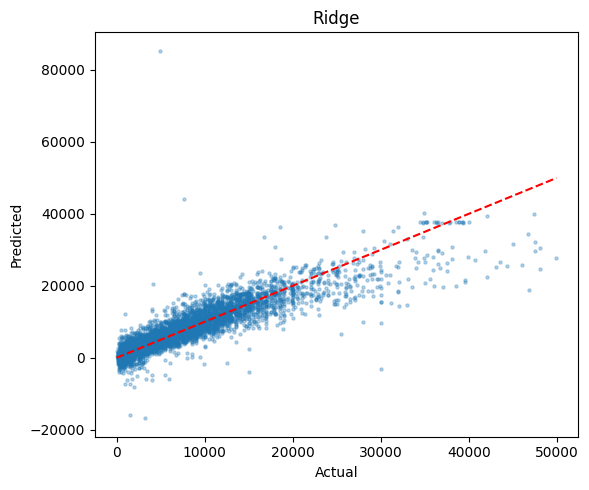

In [39]:
pg_ridge = {
    "poly__degree": [1],
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

ridge_grid, p1 = run_search(Ridge(), pg_ridge, "grid")
ridge_rnd,  p2 = run_search(Ridge(), pg_ridge, "random", n_iter=5)

def obj_ridge(trial):
    alpha  = trial.suggest_float("alpha", 1e-3, 10, log=True)
    degree = trial.suggest_int("degree", 1, 2)
    return cross_val_score(
        create_pipeline(Ridge(alpha=alpha), degree),
        X_train, y_train, cv=CV_FOLDS, scoring='r2', n_jobs=1
    ).mean()

study_ridge = optuna.create_study(direction="maximize")
study_ridge.optimize(obj_ridge, n_trials=10)
bp = study_ridge.best_params
ridge_opt = create_pipeline(Ridge(alpha=bp["alpha"]), bp["degree"])
ridge_opt.fit(X_train, y_train)

scores = {"Grid":   r2_score(y_test, ridge_grid.predict(X_test)),
          "Random": r2_score(y_test, ridge_rnd.predict(X_test)),
          "Optuna": r2_score(y_test, ridge_opt.predict(X_test))}
for m, s in scores.items():
    print(f"{m:8s}: R²={s:.4f}")

model_ridge = max([(ridge_grid, "Grid"), (ridge_rnd, "Random"), (ridge_opt, "Optuna")],
                  key=lambda x: r2_score(y_test, x[0].predict(X_test)))
print()
print(f"Лучший метод: {model_ridge[1]}")
model_ridge = model_ridge[0]
add_results("Ridge", model_ridge)

### 3.2.4. ElasticNet (L1 + L2)

Особенности модели:
- сочетает L1- и L2-регуляризацию в одной модели;
- одновременно уменьшает коэффициенты и может отбирать признаки;
- полезна как компромисс между поведением Lasso и Ridge.

Grid    : R²=0.7309
Random  : R²=0.7308
Optuna  : R²=0.8107

Лучший метод: Optuna


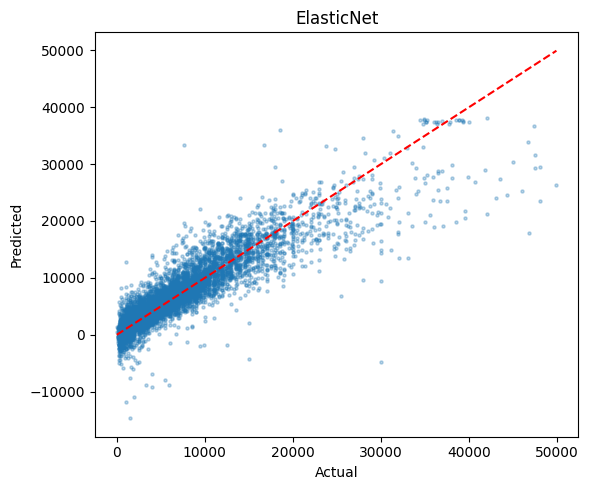

In [40]:
pg_elastic = {
    "poly__degree": [1],
    "model__alpha":    [0.001, 0.01, 0.1, 1],
    "model__l1_ratio": [0.2, 0.5, 0.8]
}

elastic_grid, p1 = run_search(ElasticNet(max_iter=5000), pg_elastic, "grid")
elastic_rnd,  p2 = run_search(ElasticNet(max_iter=5000), pg_elastic, "random", n_iter=5)

def obj_elastic(trial):
    alpha    = trial.suggest_float("alpha", 1e-4, 10, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.1, 0.9)
    degree   = trial.suggest_int("degree", 1, 2)
    return cross_val_score(
        create_pipeline(ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=5000), degree),
        X_train, y_train, cv=CV_FOLDS, scoring='r2', n_jobs=1
    ).mean()

study_elastic = optuna.create_study(direction="maximize")
study_elastic.optimize(obj_elastic, n_trials=10)
bp = study_elastic.best_params
elastic_opt = create_pipeline(
    ElasticNet(alpha=bp["alpha"], l1_ratio=bp["l1_ratio"], max_iter=5000), bp["degree"]
)
elastic_opt.fit(X_train, y_train)

scores = {"Grid":   r2_score(y_test, elastic_grid.predict(X_test)),
          "Random": r2_score(y_test, elastic_rnd.predict(X_test)),
          "Optuna": r2_score(y_test, elastic_opt.predict(X_test))}
for m, s in scores.items():
    print(f"{m:8s}: R²={s:.4f}")

model_elastic = max([(elastic_grid, "Grid"), (elastic_rnd, "Random"), (elastic_opt, "Optuna")],
                    key=lambda x: r2_score(y_test, x[0].predict(X_test)))
print()
print(f"Лучший метод: {model_elastic[1]}")
model_elastic = model_elastic[0]
add_results("ElasticNet", model_elastic)

## 3.3. Полиномиальная регрессия (Pipeline + Optuna)

Демонстрируем Pipeline: `PolynomialFeatures(degree) → StandardScaler → LinearRegression`.  
Optuna подбирает степень. **Ограничение: degree ≤ 2** — при 47 признаках degree=3 даёт ~18 000 столбцов.

Особенности модели:
- позволяет учитывать нелинейные зависимости между признаками и целевой переменной;
- создаёт новые полиномиальные признаки и взаимодействия между ними;
- при слишком большой степени быстро растёт число признаков и риск переобучения.

Лучшая степень: 1


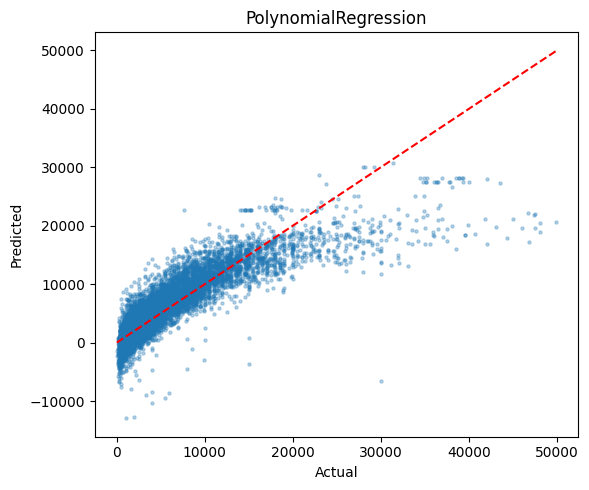

In [41]:
def obj_poly(trial):
    degree = trial.suggest_int("degree", 1, 2)
    return cross_val_score(
        create_pipeline(LinearRegression(), degree),
        X_train, y_train, cv=CV_FOLDS, scoring='r2', n_jobs=1
    ).mean()

study_poly = optuna.create_study(direction="maximize")
study_poly.optimize(obj_poly, n_trials=8)

bp = study_poly.best_params
model_poly = create_pipeline(LinearRegression(), bp["degree"])
model_poly.fit(X_train, y_train)
print(f"Лучшая степень: {bp['degree']}")
add_results("PolynomialRegression", model_poly)

## 3.4. Байесовская регрессия

`BayesianRidge` — вероятностный подход: параметры модели рассматриваются как случайные величины с априорными распределениями (Gamma).  
Гиперпараметры `alpha_1`, `alpha_2` задают форму априорного распределения на дисперсию шума.

Особенности модели:
- оценивает коэффициенты с учётом априорной информации и неопределённости;
- автоматически сглаживает слишком большие коэффициенты;
- полезна, когда важна более устойчивая оценка параметров и интерпретация неопределённости.

Grid    : R²=0.7308
Random  : R²=0.7308
Optuna  : R²=0.7308

Лучший метод: Grid


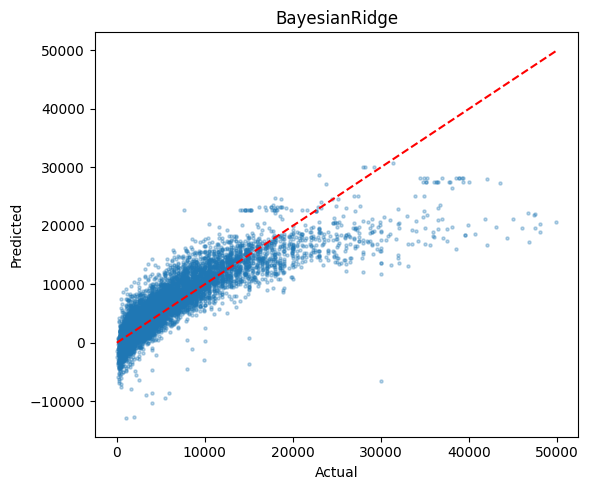

In [42]:
pg_bayes = {
    "model__alpha_1": [1e-6, 1e-4, 1e-2],
    "model__alpha_2": [1e-6, 1e-4, 1e-2]
}

bayes_grid, p1 = run_search(BayesianRidge(), pg_bayes, "grid", simple=True)
bayes_rnd,  p2 = run_search(BayesianRidge(), pg_bayes, "random", n_iter=5, simple=True)

def obj_bayes(trial):
    alpha_1 = trial.suggest_float("alpha_1", 1e-7, 1e-2, log=True)
    alpha_2 = trial.suggest_float("alpha_2", 1e-7, 1e-2, log=True)
    pipe = create_simple_pipeline(BayesianRidge(alpha_1=alpha_1, alpha_2=alpha_2))
    return cross_val_score(pipe, X_train, y_train, cv=CV_FOLDS, scoring='r2', n_jobs=1).mean()

study_bayes = optuna.create_study(direction="maximize")
study_bayes.optimize(obj_bayes, n_trials=8)
bp = study_bayes.best_params
bayes_opt = create_simple_pipeline(BayesianRidge(alpha_1=bp["alpha_1"], alpha_2=bp["alpha_2"]))
bayes_opt.fit(X_train, y_train)

scores = {"Grid":   r2_score(y_test, bayes_grid.predict(X_test)),
          "Random": r2_score(y_test, bayes_rnd.predict(X_test)),
          "Optuna": r2_score(y_test, bayes_opt.predict(X_test))}
for m, s in scores.items():
    print(f"{m:8s}: R²={s:.4f}")

model_bayes = max([(bayes_grid, "Grid"), (bayes_rnd, "Random"), (bayes_opt, "Optuna")],
                  key=lambda x: r2_score(y_test, x[0].predict(X_test)))
print()
print(f"Лучший метод: {model_bayes[1]}")
model_bayes = model_bayes[0]
add_results("BayesianRidge", model_bayes)

## 3.5. Робастная регрессия

`HuberRegressor` устойчив к выбросам — заменяет квадратичные потери на линейные для аномальных точек.  
Параметр `epsilon` регулирует порог: чем меньше — тем агрессивнее игнорирует выбросы.

Особенности модели:
- менее чувствительна к выбросам, чем обычная линейная регрессия;
- сочетает свойства MSE и MAE в одной функции потерь;
- хорошо подходит для данных, где встречаются аномально дорогие или дешёвые автомобили.

Grid    : R²=0.7111
Random  : R²=0.7111
Optuna  : R²=0.7262

Лучший метод: Optuna


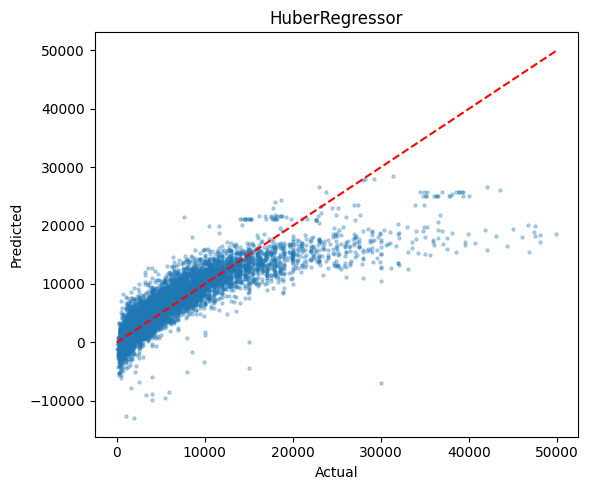

In [43]:
pg_huber = {
    "model__epsilon": [1.1, 1.35, 1.5],
    "model__alpha":   [1e-4, 1e-3, 0.01]
}

huber_grid, p1 = run_search(HuberRegressor(max_iter=200), pg_huber, "grid", simple=True)
huber_rnd,  p2 = run_search(HuberRegressor(max_iter=200), pg_huber, "random", n_iter=5, simple=True)

def obj_huber(trial):
    epsilon = trial.suggest_float("epsilon", 1.05, 2.5)
    alpha   = trial.suggest_float("alpha", 1e-5, 0.1, log=True)
    pipe = create_simple_pipeline(HuberRegressor(epsilon=epsilon, alpha=alpha, max_iter=200))
    return cross_val_score(pipe, X_train, y_train, cv=CV_FOLDS, scoring='r2', n_jobs=1).mean()

study_huber = optuna.create_study(direction="maximize")
study_huber.optimize(obj_huber, n_trials=8)
bp = study_huber.best_params
huber_opt = create_simple_pipeline(HuberRegressor(epsilon=bp["epsilon"], alpha=bp["alpha"], max_iter=200))
huber_opt.fit(X_train, y_train)

scores = {"Grid":   r2_score(y_test, huber_grid.predict(X_test)),
          "Random": r2_score(y_test, huber_rnd.predict(X_test)),
          "Optuna": r2_score(y_test, huber_opt.predict(X_test))}
for m, s in scores.items():
    print(f"{m:8s}: R²={s:.4f}")

model_huber = max([(huber_grid, "Grid"), (huber_rnd, "Random"), (huber_opt, "Optuna")],
                  key=lambda x: r2_score(y_test, x[0].predict(X_test)))
print()
print(f"Лучший метод: {model_huber[1]}")
model_huber = model_huber[0]
add_results("HuberRegressor", model_huber)

## 4. Таблица 1 — Train Data | Test Data (Образец 1)

In [44]:
cols_t1 = [
    "Train R2", "Train MSE", "Train RMSE", "Train MAE", "Train MAPE",
    "Test R2", "Test MSE", "Test RMSE", "Test MAE", "Test MAPE"
]

df_t1 = pd.DataFrame(results_t1).set_index("Регрессор")[cols_t1].sort_values("Test R2", ascending=False)
df_t1

,Train R2,Train MSE,Train RMSE,Train MAE,Train MAPE,Test R2,Test MSE,Test RMSE,Test MAE,Test MAPE
Регрессор,,,,,,,,,,
ElasticNet,0.8260,7.216164e+06,2686.2918,1709.3447,0.9464,0.8107,7.656547e+06,2767.0466,1741.9592,0.8050
Ridge,0.8449,6.433136e+06,2536.3628,1611.9893,0.8637,0.8032,7.956894e+06,2820.7966,1668.7045,0.8089
MultipleLinearRegression,0.7278,1.128982e+07,3360.0332,2139.0483,1.2348,0.7308,1.088588e+07,3299.3750,2128.9040,1.2338
Lasso,0.7277,1.129190e+07,3360.3420,2134.8188,1.2274,0.7308,1.088825e+07,3299.7344,2124.9719,1.2204
PolynomialRegression,0.7278,1.128982e+07,3360.0332,2139.0483,1.2348,0.7308,1.088588e+07,3299.3750,2128.9040,1.2338
BayesianRidge,0.7278,1.128985e+07,3360.0372,2138.5872,1.2341,0.7308,1.088531e+07,3299.2886,2128.3797,1.2334
HuberRegressor,0.7187,1.166728e+07,3415.7402,2031.9022,1.0796,0.7262,1.107168e+07,3327.4131,2012.9330,0.8297
SimpleLinearRegression,0.4953,2.093028e+07,4574.9627,2942.5292,1.1759,0.5039,2.006044e+07,4478.8887,2910.6575,1.8908


## 5. Таблица 2 — sklearn vs пользовательские метрики (Образец 2)

In [45]:
cols_t2 = [
    "sk R2", "sk MSE", "sk RMSE", "sk MAE", "sk MAPE",
    "my R2", "my MSE", "my RMSE", "my MAE", "my MAPE"
]

df_t2 = pd.DataFrame(results_t2).set_index("Регрессор")[cols_t2].loc[df_t1.index]
df_t2

,sk R2,sk MSE,sk RMSE,sk MAE,sk MAPE,my R2,my MSE,my RMSE,my MAE,my MAPE
Регрессор,,,,,,,,,,
ElasticNet,0.8107,7.656547e+06,2767.0466,1741.9592,0.8050,0.8107,7.656547e+06,2767.0466,1741.9592,0.8050
Ridge,0.8032,7.956894e+06,2820.7966,1668.7045,0.8089,0.8032,7.956894e+06,2820.7966,1668.7045,0.8089
MultipleLinearRegression,0.7308,1.088588e+07,3299.3750,2128.9040,1.2338,0.7308,1.088588e+07,3299.3750,2128.9040,1.2338
Lasso,0.7308,1.088825e+07,3299.7344,2124.9719,1.2204,0.7308,1.088825e+07,3299.7344,2124.9719,1.2204
PolynomialRegression,0.7308,1.088588e+07,3299.3750,2128.9040,1.2338,0.7308,1.088588e+07,3299.3750,2128.9040,1.2338
BayesianRidge,0.7308,1.088531e+07,3299.2886,2128.3797,1.2334,0.7308,1.088531e+07,3299.2886,2128.3797,1.2334
HuberRegressor,0.7262,1.107168e+07,3327.4131,2012.9330,0.8297,0.7262,1.107168e+07,3327.4131,2012.9330,0.8297
SimpleLinearRegression,0.5039,2.006044e+07,4478.8887,2910.6575,1.8908,0.5039,2.006044e+07,4478.8887,2910.6575,1.8908


## 6. Вывод

Ниже вывод формируется автоматически на основе рассчитанных метрик и коэффициентов лучшей модели.

In [46]:
best_name = df_t1['Test R2'].idxmax()
best_row = df_t1.loc[best_name]
best_model = model_registry[best_name]['model']
base_feature_names = model_registry[best_name]['feature_names']

if 'poly' in best_model.named_steps:
    poly = best_model.named_steps['poly']
    equation_features = poly.get_feature_names_out(base_feature_names)
else:
    equation_features = np.array(base_feature_names)

coefs = np.ravel(best_model.named_steps['model'].coef_)
intercept = float(np.ravel(np.atleast_1d(best_model.named_steps['model'].intercept_))[0])

coef_table = pd.DataFrame({
    'feature': equation_features,
    'coef': coefs,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

top_terms = coef_table.head(10)
top_terms_text = top_terms[['feature', 'coef']].to_string(index=False)
equation = ' + '.join(f"({row.coef:.4f})*{row.feature}" for row in top_terms.itertuples())

conclusion = f"""
## 6. Вывод

По итогам лабораторной работы решена задача регрессии для предсказания цены автомобиля `price_usd`.

Лучшая модель по метрике **Test R2**: **{best_name}**.

Метрики лучшей модели на тестовой выборке:
- R2 = {best_row['Test R2']:.4f}
- MSE = {best_row['Test MSE']:.4f}
- RMSE = {best_row['Test RMSE']:.4f}
- MAE = {best_row['Test MAE']:.4f}
- MAPE = {best_row['Test MAPE']:.4f}

Уравнение регрессии удобно записать в векторной форме:

`y = {intercept:.4f} + sum(w_i * x_i)`

Наиболее влиятельные коэффициенты модели:

```text
{top_terms_text}
```

Фрагмент развернутого уравнения по самым весомым признакам:

`y = {intercept:.4f} + {equation}`

Итоговые наблюдения:
- Простая линейная регрессия уступает моделям, использующим весь набор признаков.
- Регуляризованные модели помогают контролировать переобучение и стабилизируют качество на тесте.
- Пользовательские метрики из `metrics.py` совпадают со значениями `scikit-learn`, значит реализация корректна.
"""

display(Markdown(conclusion))


## 6. Вывод

По итогам лабораторной работы решена задача регрессии для предсказания цены автомобиля `price_usd`.

Лучшая модель по метрике **Test R2**: **ElasticNet**.

Метрики лучшей модели на тестовой выборке:
- R2 = 0.8107
- MSE = 7656546.7969
- RMSE = 2767.0466
- MAE = 1741.9592
- MAPE = 0.8050

Уравнение регрессии удобно записать в векторной форме:

`y = 6652.8871 + sum(w_i * x_i)`

Наиболее влиятельные коэффициенты модели:

```text
                          feature        coef
                  year_produced^2 1550.766263
                    year_produced 1218.846915
manufacturer_name engine_capacity -951.708887
                          state^2  903.613267
          manufacturer_name state  869.015994
                 odometer_value^2  719.300122
     engine_capacity has_warranty  710.232656
        engine_capacity feature_2 -700.715797
         odometer_value feature_7 -643.467675
  odometer_value number_of_photos -629.996442
```

Фрагмент развернутого уравнения по самым весомым признакам:

`y = 6652.8871 + (1550.7663)*year_produced^2 + (1218.8469)*year_produced + (-951.7089)*manufacturer_name engine_capacity + (903.6133)*state^2 + (869.0160)*manufacturer_name state + (719.3001)*odometer_value^2 + (710.2327)*engine_capacity has_warranty + (-700.7158)*engine_capacity feature_2 + (-643.4677)*odometer_value feature_7 + (-629.9964)*odometer_value number_of_photos`

Итоговые наблюдения:
- Простая линейная регрессия уступает моделям, использующим весь набор признаков.
- Регуляризованные модели помогают контролировать переобучение и стабилизируют качество на тесте.
- Пользовательские метрики из `metrics.py` совпадают со значениями `scikit-learn`, значит реализация корректна.


## 7. Интеллект-карта

Ниже изображение интеллект-карты по выполненной лабораторной работе генерируется прямо в ноутбуке.

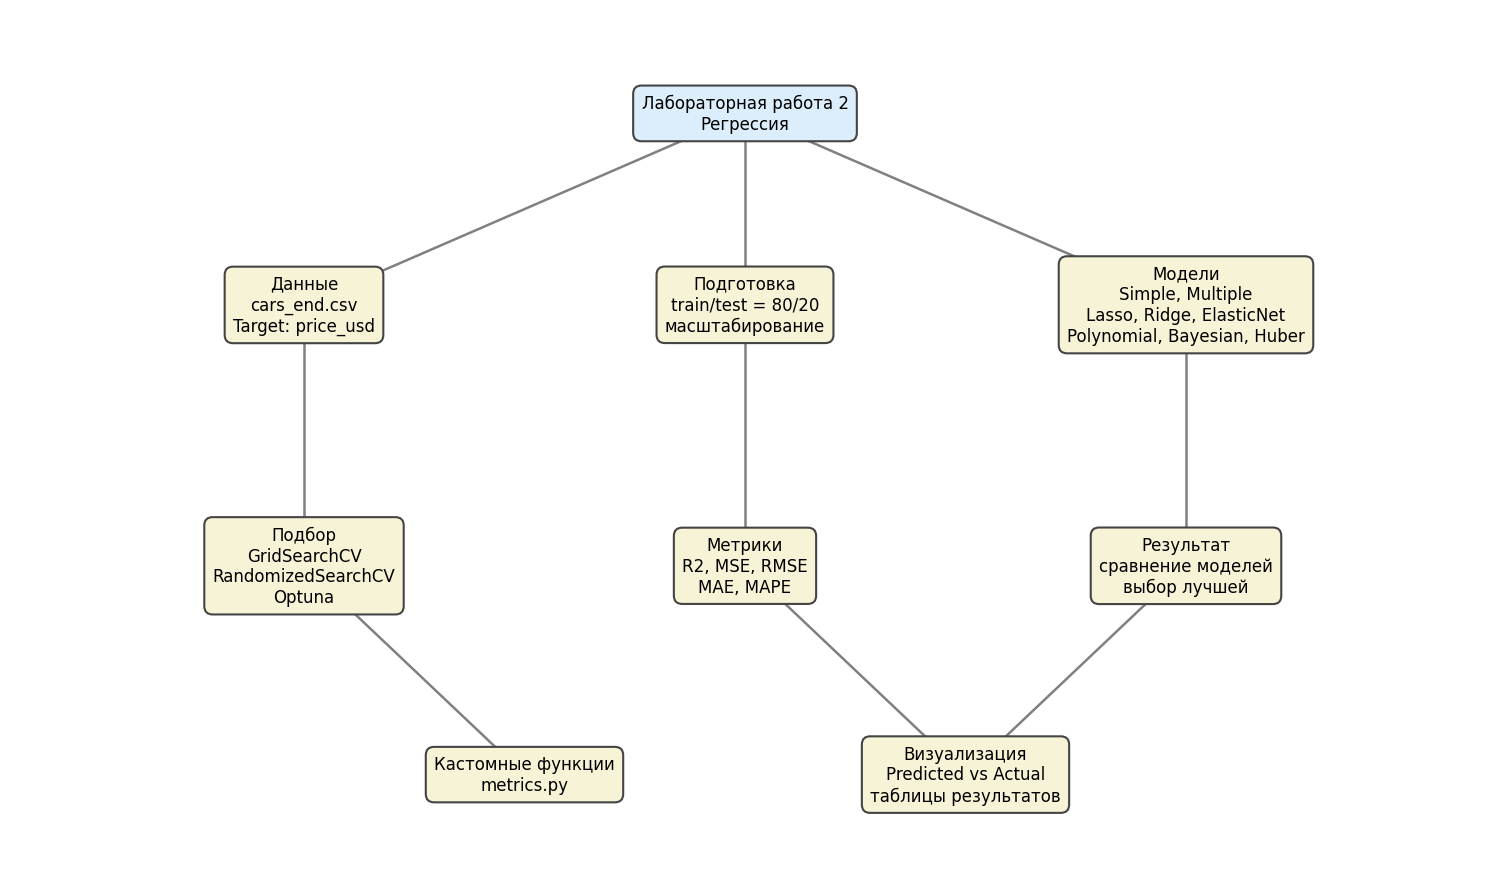

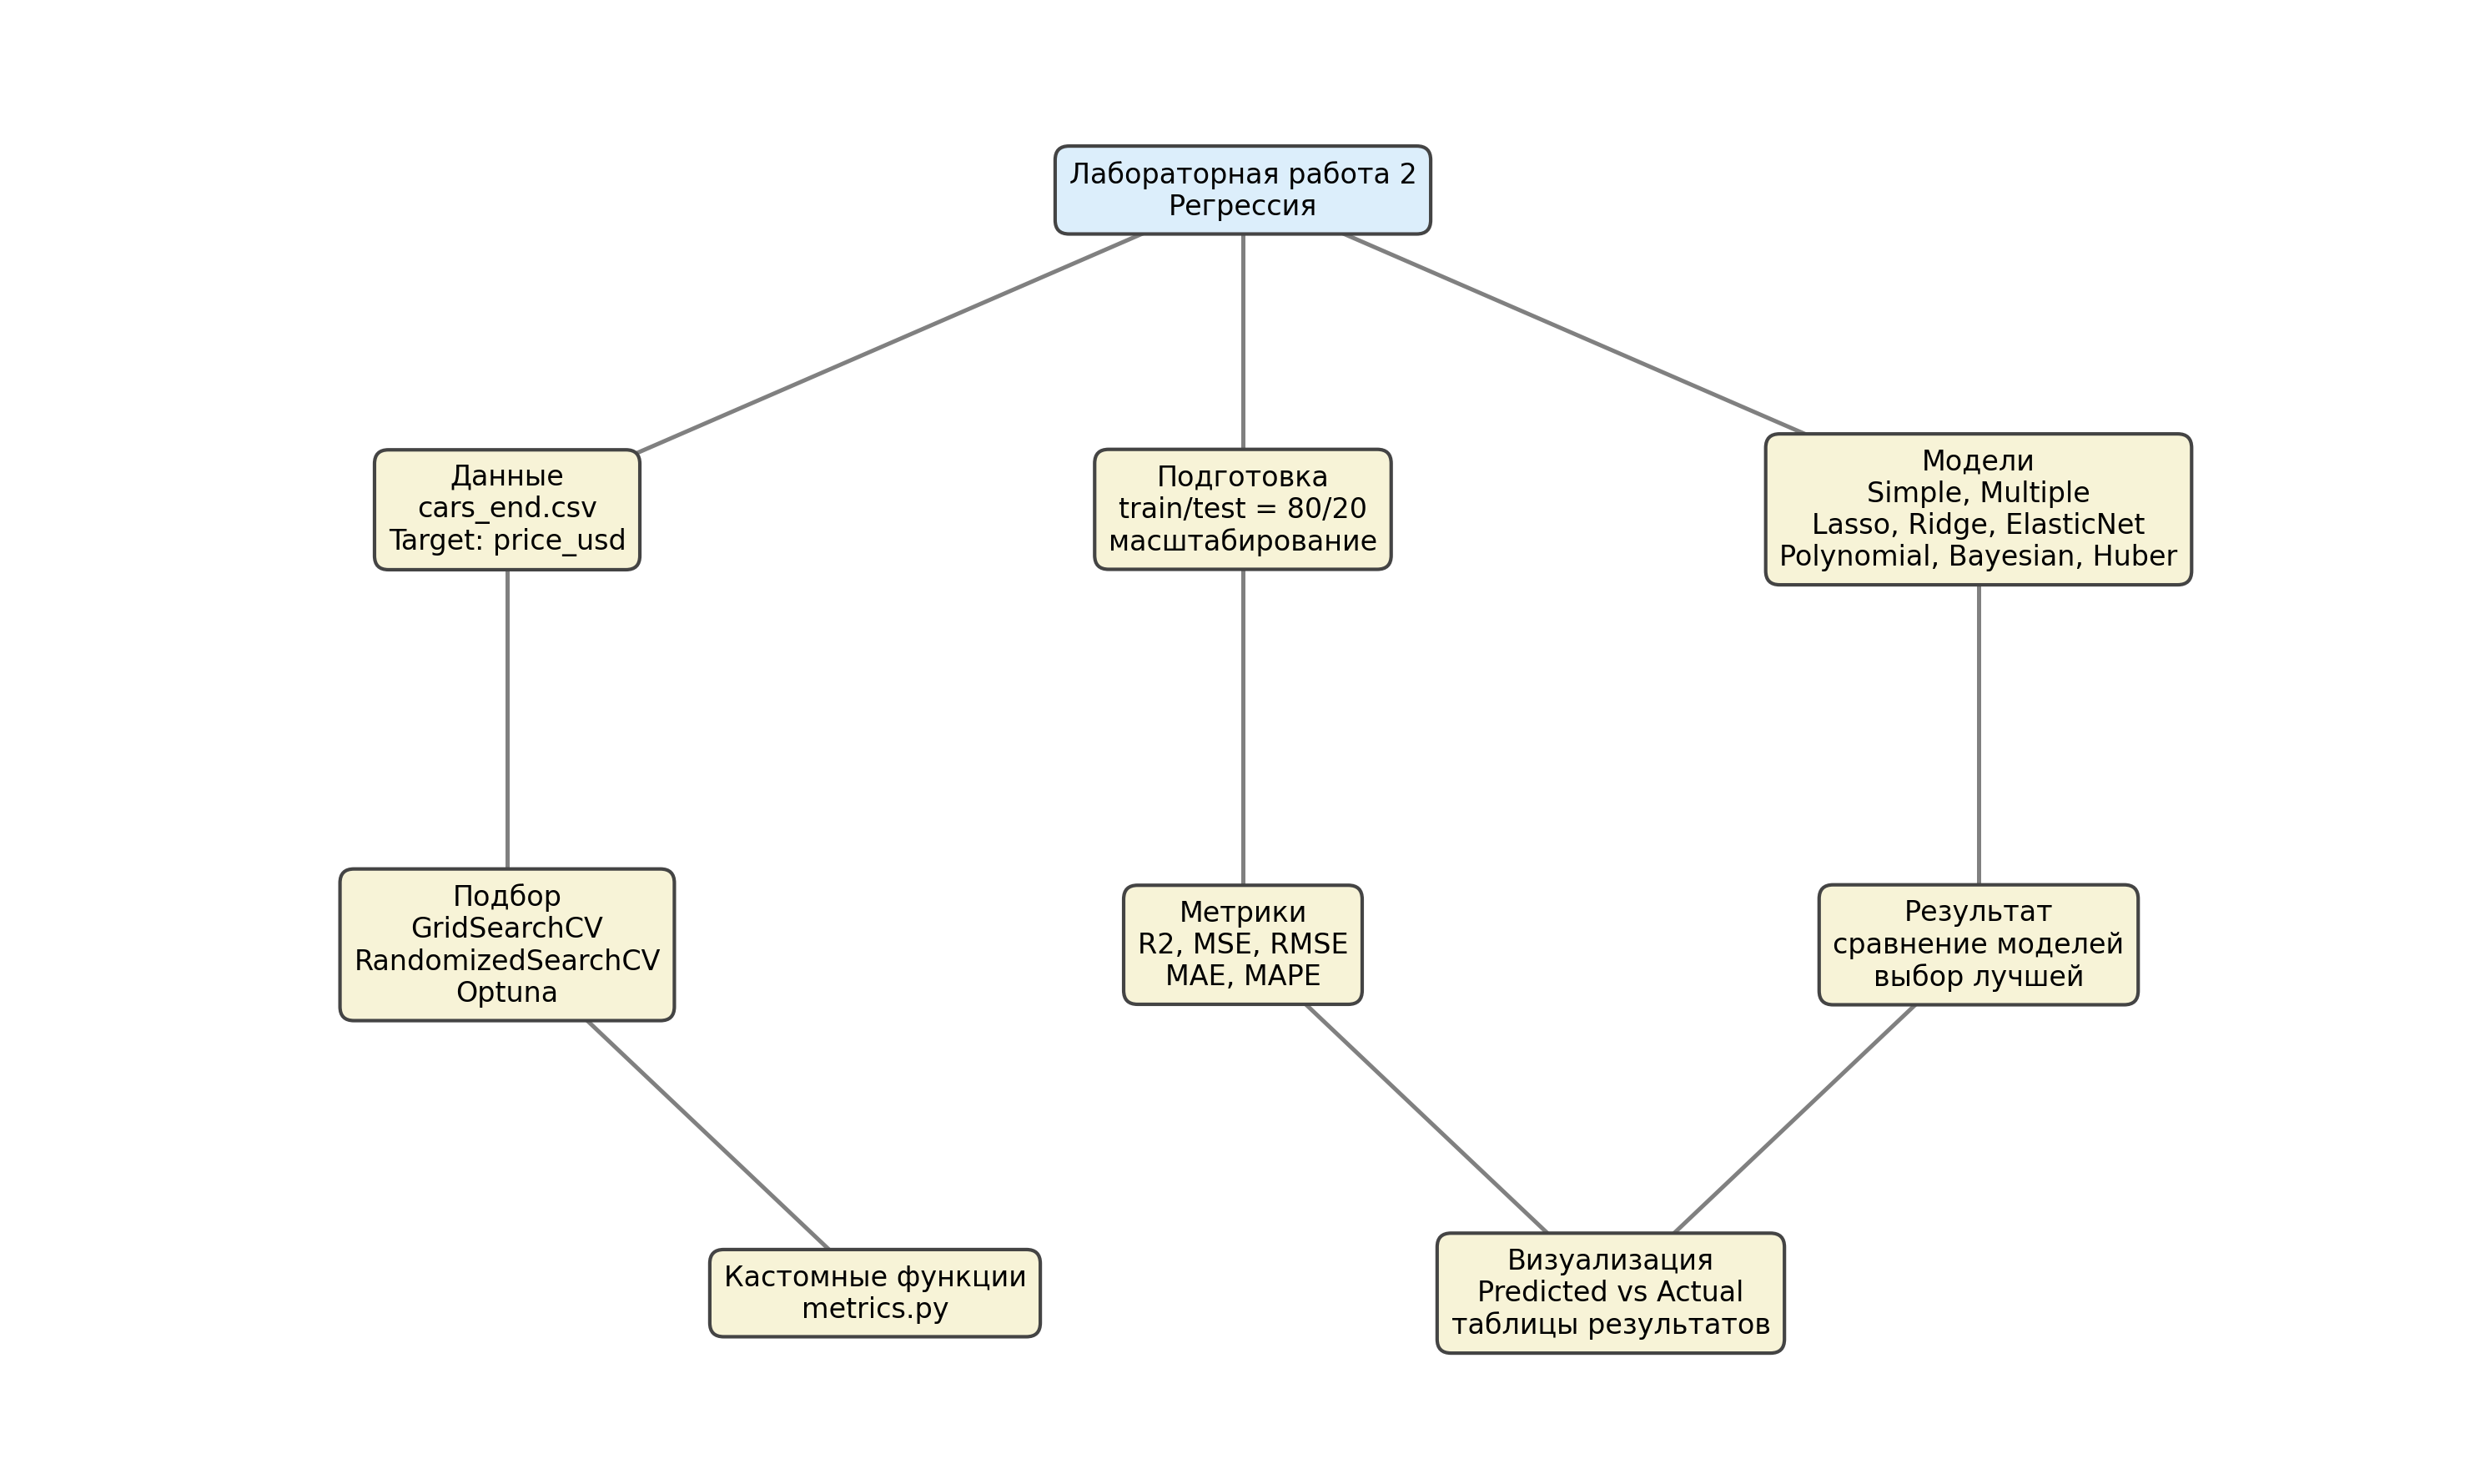

In [47]:
fig, ax = plt.subplots(figsize=(15, 9))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

nodes = {
    'lab': (0.5, 0.88, 'Лабораторная работа 2\nРегрессия'),
    'data': (0.2, 0.66, 'Данные\ncars_end.csv\nTarget: price_usd'),
    'prep': (0.5, 0.66, 'Подготовка\ntrain/test = 80/20\nмасштабирование'),
    'models': (0.8, 0.66, 'Модели\nSimple, Multiple\nLasso, Ridge, ElasticNet\nPolynomial, Bayesian, Huber'),
    'search': (0.2, 0.36, 'Подбор\nGridSearchCV\nRandomizedSearchCV\nOptuna'),
    'metrics': (0.5, 0.36, 'Метрики\nR2, MSE, RMSE\nMAE, MAPE'),
    'result': (0.8, 0.36, 'Результат\nсравнение моделей\nвыбор лучшей'),
    'custom': (0.35, 0.12, 'Кастомные функции\nmetrics.py'),
    'viz': (0.65, 0.12, 'Визуализация\nPredicted vs Actual\nтаблицы результатов')
}

edges = [
    ('lab', 'data'), ('lab', 'prep'), ('lab', 'models'),
    ('data', 'search'), ('prep', 'metrics'), ('models', 'result'),
    ('search', 'custom'), ('metrics', 'viz'), ('result', 'viz')
]

for start, end in edges:
    x1, y1, _ = nodes[start]
    x2, y2, _ = nodes[end]
    ax.plot([x1, x2], [y1, y2], color='gray', linewidth=1.8, zorder=1)

for key, (x, y, text) in nodes.items():
    color = '#dceefb' if key == 'lab' else '#f7f3d7'
    ax.text(
        x, y, text,
        ha='center', va='center', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.5', facecolor=color, edgecolor='#444444', linewidth=1.5),
        zorder=2
    )

plt.tight_layout()
plt.savefig('mindmap_lab2.png', dpi=200, bbox_inches='tight')
plt.show()
Image('mindmap_lab2.png')